In [1]:
import sys
sys.path.insert(0, '../lib/')

In [2]:
import os
import pickle
import warnings
import pathlib
import itertools

import pandas as pd
import numpy as np
import xgboost
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import common_data
import common_plots
import shap

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
common_plots.setup_plotting()

In [4]:
%config InlineBackend.figure_format = "retina"

In [5]:
pd.options.display.max_rows = 100

# XGBoost baselines for EHRformer tasks

We'll use XGBoost with default parameters on unbinned data for the same tasks and splits as EHRformer

In [6]:
ehr = pd.read_csv(common_data.CLINICAL, index_col=0)

In [7]:
ehr_labels = pd.read_csv(common_data.CLINICAL_LABELS, index_col=0)

In [ ]:
EHR_FILE_PATH = common_data.EHRFORMER_BINS
with open(EHR_FILE_PATH, 'rb') as pickle_handle:
    ehr_binned = pickle.load(pickle_handle)

Which features were used for EHRformer?

In [9]:
ehr_features = ehr_binned.columns.to_frame()[0].unique()
sorted(ehr_features)

['ABG_PaCO2',
 'ABG_PaO2',
 'ABG_pH',
 'Age',
 'Albumin',
 'BMI',
 'Bicarbonate',
 'Bilirubin',
 'CRRT_flag',
 'Creatinine',
 'Diastolic_blood_pressure',
 'FiO2',
 'FiO2_changes',
 'GCS_eye_opening',
 'GCS_motor_response',
 'GCS_verbal_response',
 'Gender',
 'Heart_rate',
 'Hemodialysis_flag',
 'Hemoglobin',
 'ICU_stay',
 'Immunocompromised_flag',
 'Intubation_flag',
 'LDH',
 'Lactic_acid',
 'Lung_Compliance',
 'Lymphocytes',
 'Mean_arterial_pressure',
 'Minute_Ventilation',
 'Neutrophils',
 'Norepinephrine_rate',
 'Oxygen_saturation',
 'PEEP',
 'PEEP_changes',
 'PaO2FIO2_ratio',
 'Plateau_Pressure',
 'Platelets',
 'Procalcitonin',
 'RASS_score',
 'Respiratory_rate',
 'Respiratory_rate_changes',
 'Steroid_dose',
 'Systolic_blood_pressure',
 'Temperature',
 'Urine_output',
 'WBC_count',
 'day_of_hospitalization',
 'days_on_ventilator',
 'mean_nat_score_until_yesterday',
 'week_of_hospitalization']

Are they all present in EHR data?

In [10]:
for f in ehr_features:
    if f not in ehr.columns and f not in ehr_labels.columns:
        print(f)

Let's compile the dataframe

In [11]:
xgboost_ehr = ehr.loc[:, ehr.columns.isin(ehr_features)].merge(
    ehr_labels.loc[:, ehr_labels.columns.isin(ehr_features) & ~ehr_labels.columns.isin(ehr.columns)],
    left_index=True,
    right_index=True
)

In [12]:
xgboost_ehr.shape

(15287, 50)

Sort labels by data, to make them the same

In [13]:
ehr_labels = ehr_labels.loc[xgboost_ehr.index]

In [14]:
xgboost_ehr.Gender = pd.Categorical(xgboost_ehr.Gender)

In [15]:
def compute_metrics(data: xgboost.DMatrix, y_probs: np.ndarray) -> dict:
    y_pred = y_probs > 0.5
    y_true = data.get_label()
    n_neg = (y_true == 0).sum()
    n_pos = (y_true == 1).sum()
    auprc_baseline = n_pos / y_true.shape[0]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        auprc = sklearn.metrics.average_precision_score(y_true, y_probs)
        f1_binary = sklearn.metrics.f1_score(y_true, y_pred, average='binary')
        roc_auc = sklearn.metrics.roc_auc_score(y_true, y_probs)
        accuracy = sklearn.metrics.accuracy_score(y_true, y_pred)
        recall = sklearn.metrics.recall_score(y_true=y_true, y_pred=y_pred)
        precision = sklearn.metrics.precision_score(y_true=y_true, y_pred=y_pred)

    return {
        'accuracy': accuracy,
        'f1_binary': f1_binary,
        'AUROC': roc_auc,
        'AUPRC': auprc,
        'AUPRC_baseline': auprc_baseline,
        'n_neg': n_neg,
        'n_pos': n_pos,
        'recall': recall,
        'precision': precision,
    }

In [16]:
def get_train_test_data(
        data: pd.DataFrame,
        ehr_labels: pd.DataFrame,
        task_info: common_data.TaskInfo
) -> tuple[xgboost.DMatrix, xgboost.DMatrix]:
    train_idx = ehr_labels[task_info.split_column].eq('train')
    test_idx = ehr_labels[task_info.split_column].eq('test')
    if task_info.pathname == 'any_pathogen':
        y_train = ehr_labels[task_info.column].ne(task_info.column_values[0]).astype(int)[train_idx]
        y_test = ehr_labels[task_info.column].ne(task_info.column_values[0]).astype(int)[test_idx]
    else:
        train_idx &= ehr_labels[task_info.column].isin(task_info.column_values)
        test_idx &= ehr_labels[task_info.column].isin(task_info.column_values)
        y_train = ehr_labels.loc[
            train_idx,
            task_info.column
        ].eq(task_info.column_values[1]).astype(int)
        y_test = ehr_labels.loc[
            test_idx,
            task_info.column
        ].eq(task_info.column_values[1]).astype(int)
    train_data = xgboost.DMatrix(data.loc[train_idx], label=y_train, enable_categorical=True)
    test_data = xgboost.DMatrix(data.loc[test_idx], label=y_test, enable_categorical=True)
    return train_data, test_data

How to run SHAP?

Based on https://www.nature.com/articles/s42256-019-0138-9
https://github.com/christophM/interpretable-ml-book/issues/142
https://github.com/shap/shap/issues/882
https://github.com/shap/shap/issues/1098

I chose to run SHAP in `interventional` method, and supply train data for each model.
I have not done systematic comparison against the `tree_path_dependent` method, but for one model
results were quite similar. Our model does output probabilities, so that's that

In [17]:
base_dir = pathlib.Path('./03_xgboost_models')
results = {}
for task in common_data.get_tasks(context='ehrformer') + ['any_pathogen']:
    if task == 'viral_vs_bacterial':
        continue
    if task.startswith('H_'):
        continue
    results[task] = {}
    for split_num in range(1, 5):
        split = f'split_{split_num}'
        results[task][split] = {}
        if task == 'any_pathogen':
            task_info = common_data.TaskInfo(
                task,
                column='perturbation_groups_2',
                column_values=['NPC'],
                split_column=f'test_split_pg2_split_{split_num}'
            )
        else:
            task_info = common_data.get_task_info(task, split)

        train_data, test_data = get_train_test_data(xgboost_ehr, ehr_labels, task_info)
        model = xgboost.Booster()
        model.load_model(base_dir / task / f'{split}.json')
        probs = model.predict(test_data)
        preds = probs > 0.5
        correct_mask = preds == test_data.get_label()
        for target in (0, 1):
            target_mask = test_data.get_label() == target
            mask = target_mask & correct_mask
            if mask.sum() == 0:
                continue
            shap_values = shap.TreeExplainer(
                model,
                data=train_data.get_data().todense(),
                model_output='probability'
            )((pd.DataFrame(
                test_data.get_data().todense()[target_mask & correct_mask],
                columns=test_data.feature_names
            )))
            results[task][split][target] = np.abs(shap_values.values).mean(axis=0)

In [18]:
# Take average attention for each task and split across 5 models
summary_df = []
for task, task_data in results.items():
    for split, split_data in task_data.items():
        shap_values = {}
        for target, shaps in split_data.items():
            for i in range(len(shaps)):
                summary_df.append({
                    'task': task.replace(' aeruginosa', ''),
                    'split': split,
                    'target': target,
                    'feature': test_data.feature_names[i],
                    'mean_abs_shap': shaps[i],
                })
summary_df = pd.DataFrame(summary_df)

In [19]:
summary_df = summary_df.groupby(['task', 'target', 'feature']).mean_abs_shap.mean().reset_index()

In [20]:
summary_df = summary_df.pivot_table(
    columns=['target', 'task'],
    index=['feature'],
    values=['mean_abs_shap']
)
summary_df.columns = summary_df.columns.droplevel(0)

In [21]:
PATH_ORDER = [
    'any_pathogen',
    'Early SARS-CoV-2',
    'Late SARS-CoV-2',
    'Gram+',
    'Pseudomonas',
    'Gram-*',
    'Gram-*; Gram+',
    'Early SARS-CoV-2; Gram+',
    'Late SARS-CoV-2; Gram+',
    'Pseudomonas; SARS-CoV-2',
]
COL_ORDER_PATHOGEN = list(itertools.chain(
    [(0, path) for path in PATH_ORDER],
    [(1, path) for path in PATH_ORDER]
))
COL_ORDER_VAP = [
    (0, 'vap_onset_d7_empirical'),
    (0, 'is_episode_cured'),
    (1, 'vap_onset_d7_empirical'),
    (1, 'is_episode_cured')
]

In [22]:
PRETTY_NAMES = {
    'Plateau_Pressure': 'Plateau pressure',
    'Lung_Compliance': 'Lung compliance',
    'Minute_Ventilation': 'Minute ventilation',
    'PaO2FIO2_ratio': r'P$_{\mathrm{a}}$O$_2$/F$_{\mathrm{i}}$O$_2$',
    'days_on_ventilator': 'Days on ventilator',
    'day_of_hospitalization': 'Day of hospitalization',
    'week_of_hospitalization': 'Week of hospitalization',
    'mean_nat_score_until_yesterday': 'Mean NAT score until yesterday',
    'Gender': 'Sex',
    'ICU_stay': 'ICU stay number',
    'GCS_eye_opening': 'GCS eye opening score',
    'GCS_motor_response': 'GCS motor response score',
    'GCS_verbal_response': 'GCS verbal response score',
    'FiO2': r'F$_{\mathrm{i}}$O$_2$',
    'ABG_PaO2': r'P$_{\mathrm{a}}$O$_2$',
    'ABG_pH': 'pH',
    'D_dimer_ff': 'D-dimer',
    'days_of_icu_abx_until_today': 'ICU antibiotic days to date',
    'ABG_PaCO2': r'P$_{\mathrm{a}}$CO$_2$'
}
for col in ehr_features:
    if col not in PRETTY_NAMES:
        PRETTY_NAMES[col] = col.replace('_', ' ').replace(' flag', '')

In [23]:
NAMES_PATHOGEN = [
    'Any pathogen',
    'Early SARS-CoV-2',
    'Late SARS-CoV-2',
    'Gram+',
    'Pseudomonas',
    'Other Gram–',
    'Other Gram–; Gram+',
    'Early SARS-CoV-2; Gram+',
    'Late SARS-CoV-2; Gram+',
    'SARS-CoV-2; Pseudomonas'
]
NAMES_VAP = [
    'VAP onset within 7 days',
    'VAP cure in 7 days',
]

In [24]:
reverse_names = {
    abbr: full.replace(' aeruginosa', '')
    for full, abbr
    in itertools.chain(
        common_data.PATHOGENS.items()
    )
}

In [25]:
summary_df.columns = summary_df.columns.set_levels(level=1, levels=[
    '_vs_' in name and reverse_names[name.split('_vs_')[1]] or name
    for name
    in summary_df.columns.levels[1]
])

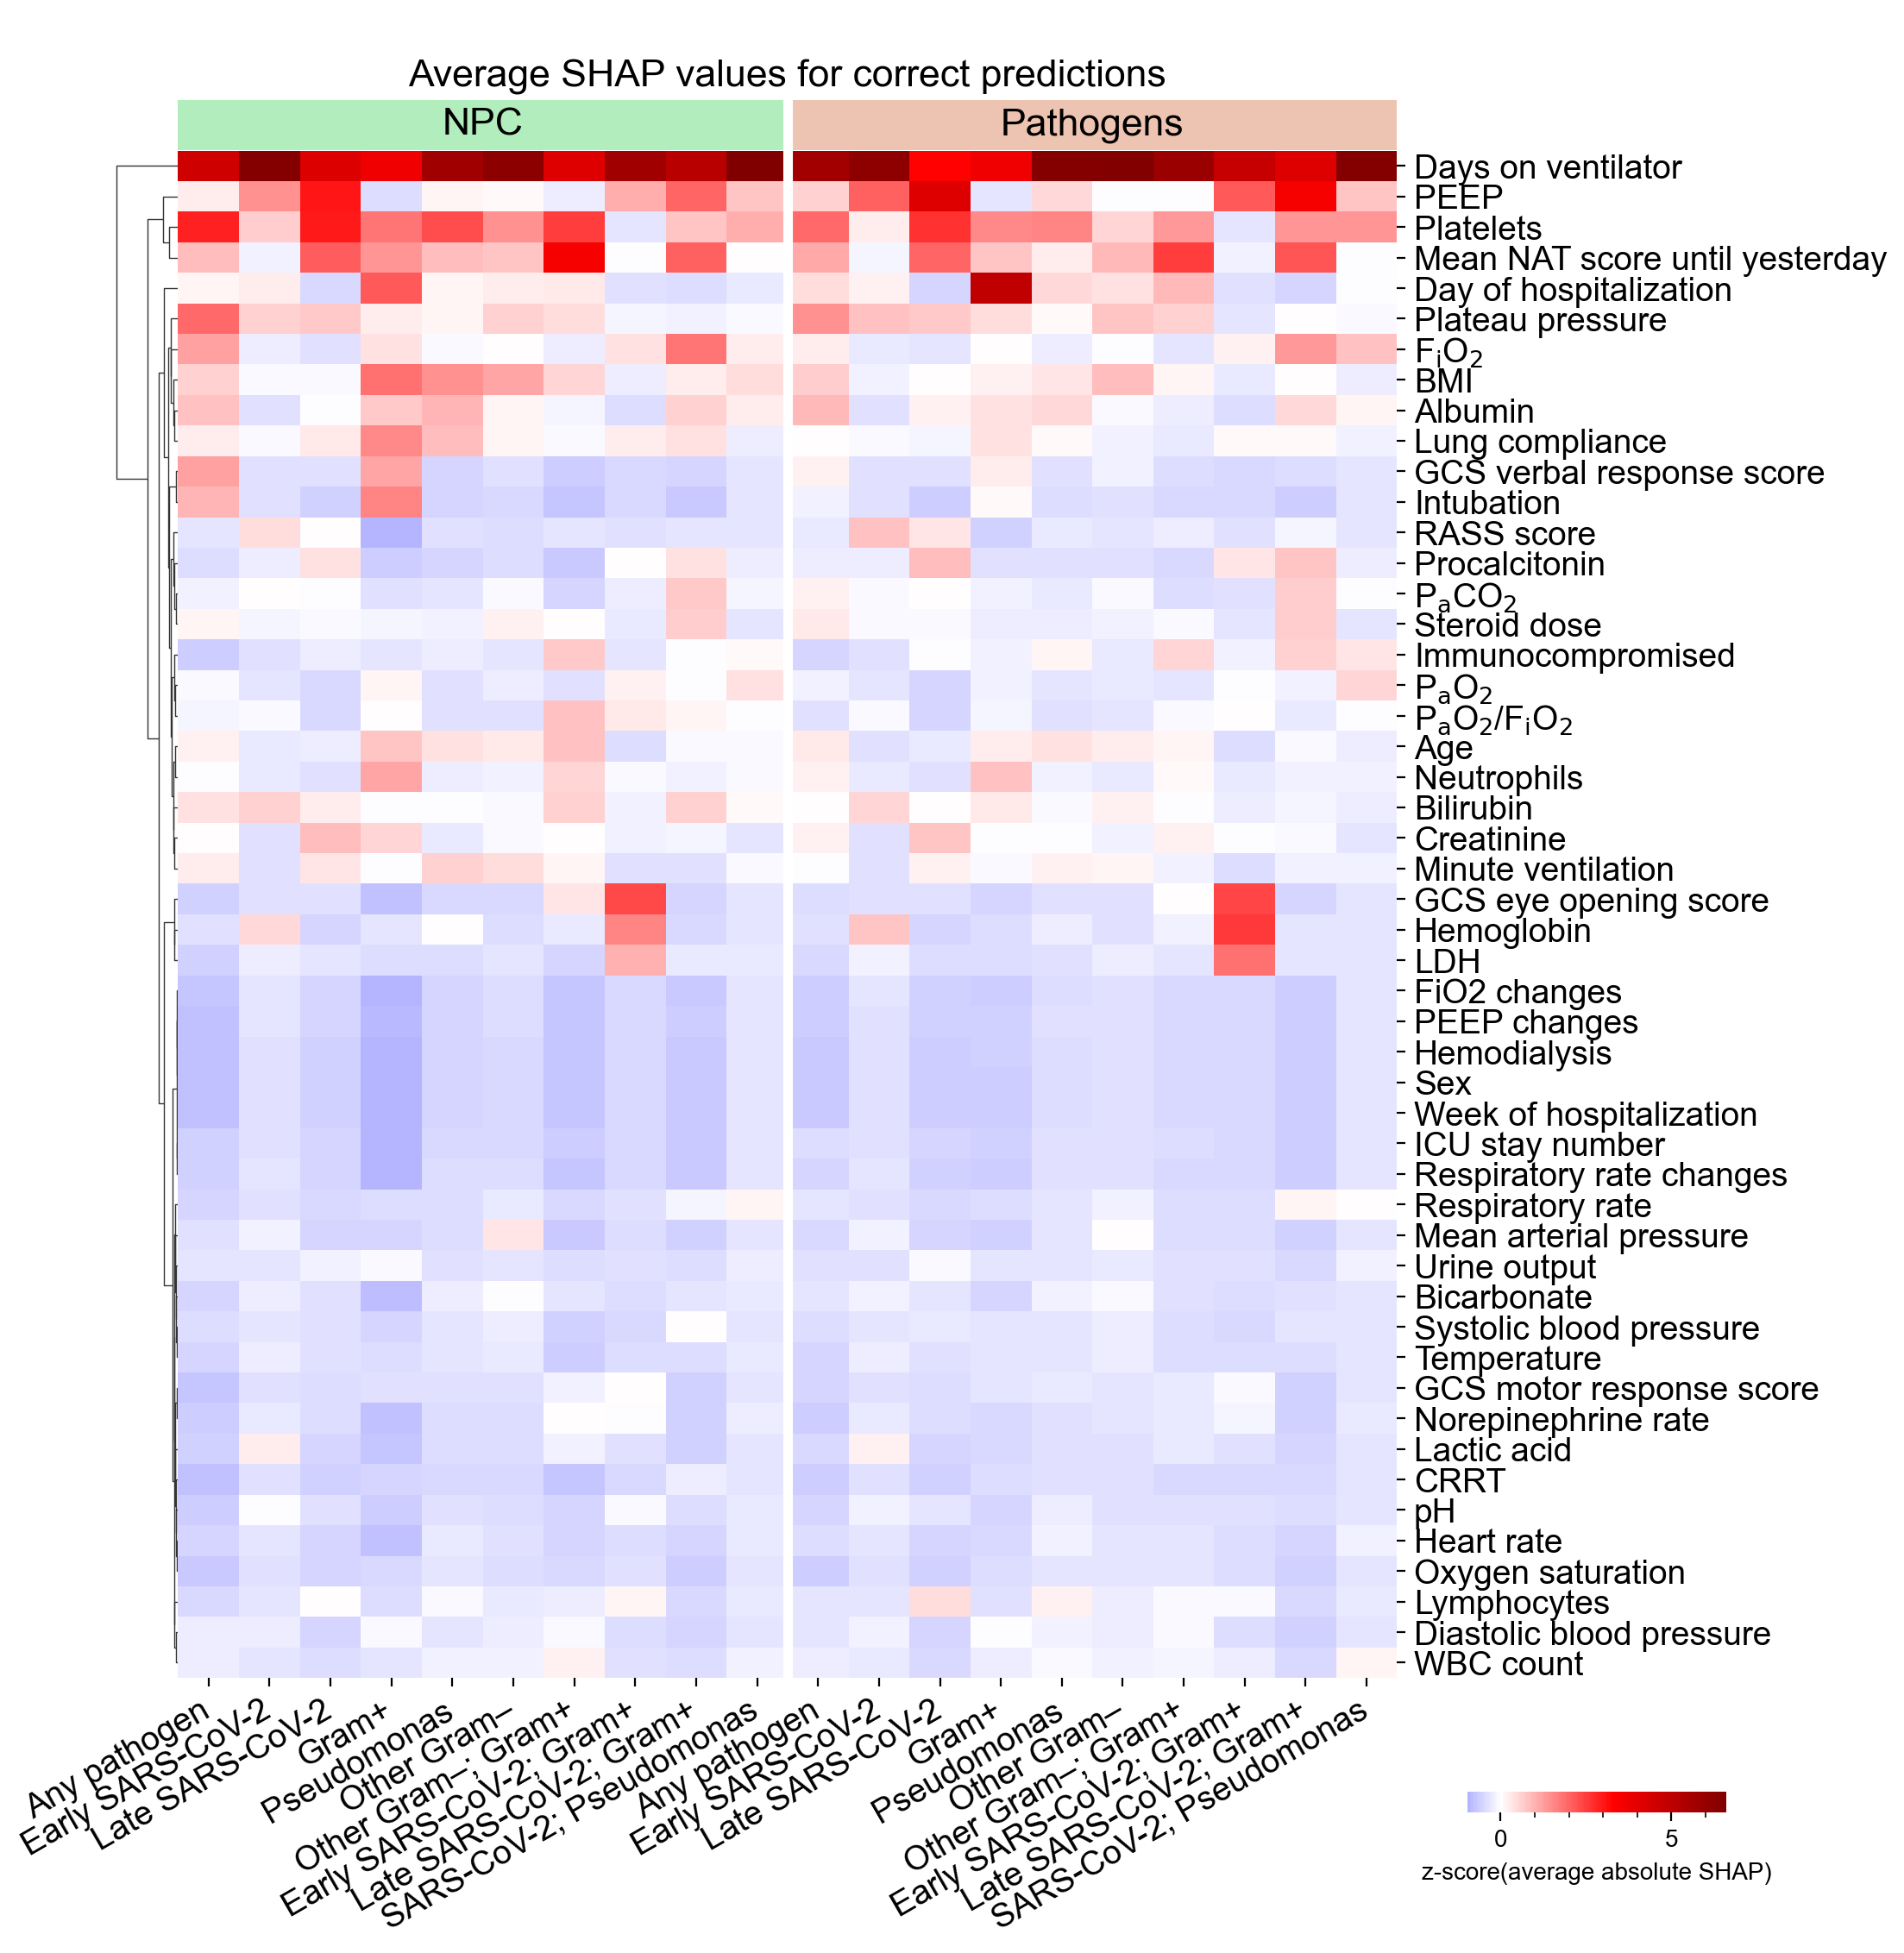

In [26]:
cg = sns.clustermap(
    summary_df.loc[:, COL_ORDER_PATHOGEN],
    cmap="seismic",
    row_cluster=True,
    col_cluster=False,
    col_colors=['#b1edbd'] * len(PATH_ORDER) + ['#edc4b1'] * len(PATH_ORDER),
    figsize=(10, 12),
    annot=False,
    z_score=1,
    center=0,
    xticklabels=NAMES_PATHOGEN * 2,
    yticklabels=[PRETTY_NAMES.get(idx, idx) for idx in summary_df.index],
    cbar_pos=(0.8, 0.12, 0.15, 0.01),
    cbar_kws=dict(
        label='z-score(average absolute SHAP)',
        orientation='horizontal',
        # ticks=[-1, 0, 1, 2, 3, 4]
    ),
    dendrogram_ratio=0.05,
    method='ward'
)

cg.ax_cbar.set_xticks([1, 2, 3, 4, 6], minor=True)

cg.ax_col_colors.set_title('Average SHAP values for correct predictions', size=16)
cg.ax_heatmap.set_xlabel('')
cg.ax_heatmap.set_ylabel('')

cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=14)
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xmajorticklabels(),
    fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

cg.ax_heatmap.axvline(len(PATH_ORDER), c='w', lw=4)
cg.ax_col_colors.axvline(len(PATH_ORDER), c='w', lw=4)

cg.ax_col_colors.text(len(PATH_ORDER) / 2, 0.5, 'NPC', ha='center', va='center', size=16)
cg.ax_col_colors.text(len(PATH_ORDER) * 1.5, 0.5, 'Pathogens', ha='center', va='center', size=16)

cg.savefig('00_plots/Fig_S3e_xgboost_shap_pathogens.pdf')

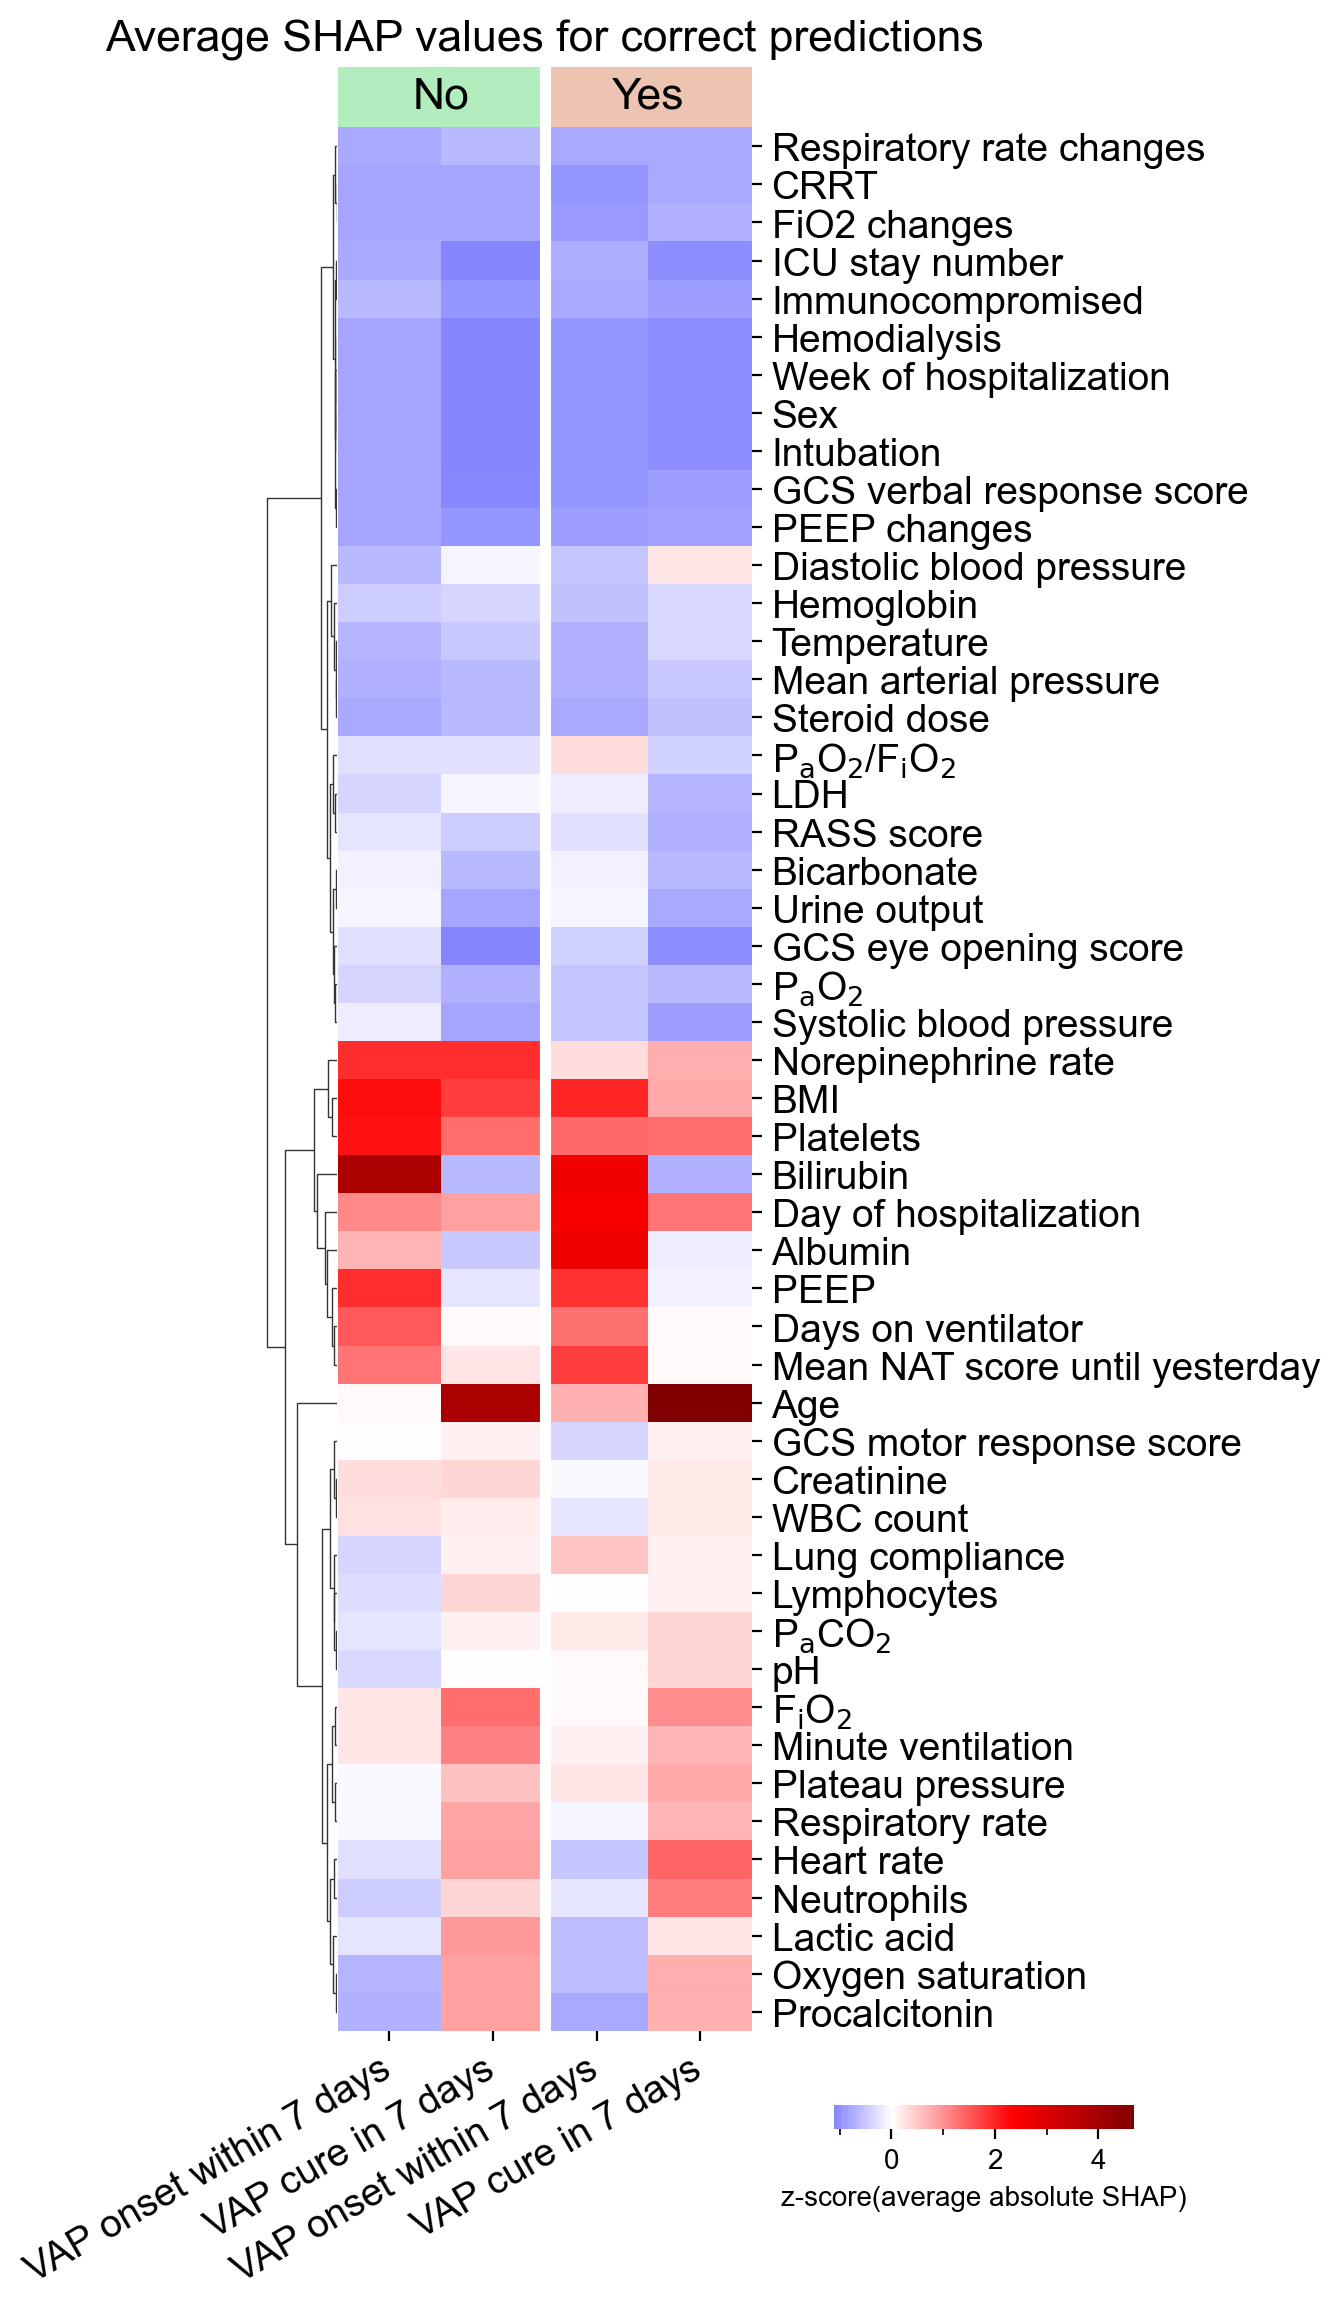

In [27]:
cg = sns.clustermap(
    summary_df.loc[:, COL_ORDER_VAP],
    cmap="seismic",
    row_cluster=True,
    col_cluster=False,
    col_colors=['#b1edbd'] * len(NAMES_VAP) + ['#edc4b1'] * len(NAMES_VAP),
    figsize=(5, 12),
    annot=False,
    z_score=1,
    center=0,
    xticklabels=NAMES_VAP * 2,
    yticklabels=[PRETTY_NAMES.get(idx, idx) for idx in summary_df.index],
    cbar_pos=(0.6, 0.12, 0.3, 0.01),
    cbar_kws=dict(
        label='z-score(average absolute SHAP)',
        orientation='horizontal',
        # ticks=[-1, 0, 1, 2, 3, 4]
    ),
    dendrogram_ratio=(0.15, 0.01),
    method='ward'
)

cg.ax_cbar.set_xticks([-1, 1, 3], minor=True)

cg.ax_col_colors.set_title('Average SHAP values for correct predictions', size=16)
cg.ax_heatmap.set_xlabel('')
cg.ax_heatmap.set_ylabel('')

cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=14)
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xmajorticklabels(),
    fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

cg.ax_heatmap.axvline(len(NAMES_VAP), c='w', lw=4)
cg.ax_col_colors.axvline(len(NAMES_VAP), c='w', lw=4)

cg.ax_col_colors.text(len(NAMES_VAP) / 2, 0.5, 'No', ha='center', va='center', size=16)
cg.ax_col_colors.text(len(NAMES_VAP) * 1.5, 0.5, 'Yes', ha='center', va='center', size=16)

cg.savefig('00_plots/Fig_S3f_xgboost_shap_vap.pdf')